# ⚽ FIFA World Cup Score Predictor
## Multi-Model Training Framework

This notebook trains multiple ML models to predict:
1. Final score (home & away goals)
2. Match outcome (win/draw/loss)
3. Total goals
4. Goal difference

### Step 0: Install Dependencies

In [1]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn -q
print("✓ Dependencies installed")

✓ Dependencies installed


### Step 1: Import & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from xgboost import XGBRegressor, XGBClassifier

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
# Load the FIFA World Cup dataset
# Download from: https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup/data

df = pd.read_csv('FIFA_WC.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (964, 44)

Columns:
['Home Team Name', 'Away Team Name', 'Home Team Goals', 'home_xg', 'home_penalty', 'Away Team Goals', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials', 'Round', 'DateTime', 'Score', 'Referee', 'Notes', 'Host', 'Year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']

First 5 rows:


,Home Team Name,Away Team Name,Home Team Goals,home_xg,home_penalty,Away Team Goals,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [ ]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nData info:")
df.info()

Missing values:
Home Team Name                       0
Away Team Name                       0
Home Team Goals                      0
home_xg                            836
home_penalty                       929
Away Team Goals                      0
away_xg                            836
away_penalty                       929
home_manager                         0
home_captain                       320
away_manager                         0
away_captain                       320
Attendance                           0
Venue                                0
Officials                          255
Round                                0
DateTime                             0
Score                                0
Referee                            255
Notes                              891
Host                                 0
Year                                 0
home_goal                          246
away_goal                          393
home_goal_long                     246
away_goal

### Step 2: Data Exploration

Goal statistics:
       Home Team Goals  Away Team Goals
count       964.000000       964.000000
mean          1.776971         1.044606
std           1.596676         1.071233
min           0.000000         0.000000
25%           1.000000         0.000000
50%           1.000000         1.000000
75%           3.000000         2.000000
max          10.000000         7.000000


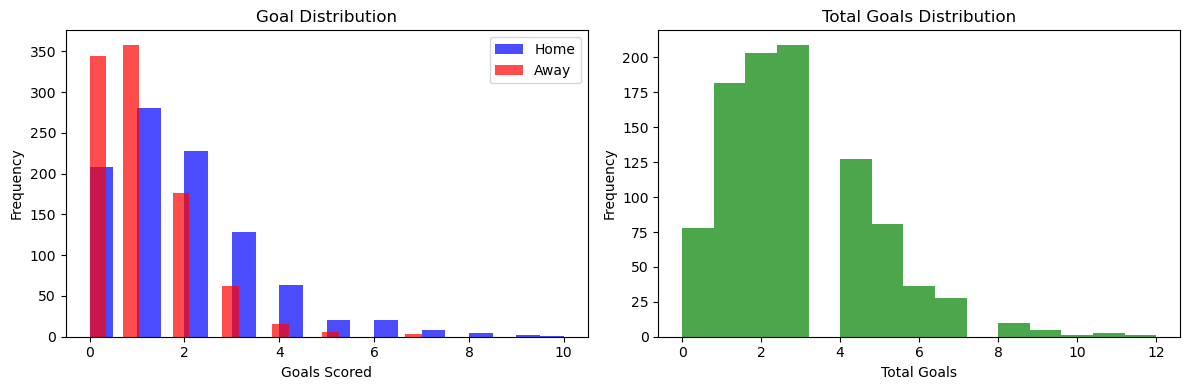


Average home goals: 1.78
Average away goals: 1.04
Average total goals per match: 2.82


In [5]:
# Basic statistics
print("Goal statistics:")
print(df[['Home Team Goals', 'Away Team Goals']].describe())

# Visualize goal distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Home Team Goals'], bins=20, alpha=0.7, label='Home', color='blue')
axes[0].hist(df['Away Team Goals'], bins=20, alpha=0.7, label='Away', color='red')
axes[0].set_xlabel('Goals Scored')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_title('Goal Distribution')

# Total goals distribution
total_goals = df['Home Team Goals'] + df['Away Team Goals']
axes[1].hist(total_goals, bins=15, color='green', alpha=0.7)
axes[1].set_xlabel('Total Goals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Total Goals Distribution')
plt.tight_layout()
plt.show()

print(f"\nAverage home goals: {df['Home Team Goals'].mean():.2f}")
print(f"Average away goals: {df['Away Team Goals'].mean():.2f}")
print(f"Average total goals per match: {total_goals.mean():.2f}")

### Step 3: Feature Engineering

In [14]:
# Create target variables
df['home_goals'] = df['Home Team Goals']
df['away_goals'] = df['Away Team Goals']
df['total_goals'] = df['home_goals'] + df['away_goals']
df['goal_difference'] = df['home_goals'] - df['away_goals']

# Outcome: 2=Home Win, 1=Draw, 0=Away Win (non-negative integers required by XGBoost)
df['outcome'] = df['goal_difference'].apply(lambda x: 2 if x > 0 else (1 if x == 0 else 0))

# Parse year
df['year'] = pd.to_datetime(df['DateTime']).dt.year

print("✓ Target variables created")
print(f"\nOutcome distribution:")
outcome_map = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
print(df['outcome'].value_counts().map(outcome_map))

✓ Target variables created

Outcome distribution:
outcome
2    NaN
0    NaN
1    NaN
Name: count, dtype: object


In [15]:
# Calculate team statistics
def calculate_team_stats(df):
    stats = {}
    all_teams = set(df['Home Team Name'].unique()) | set(df['Away Team Name'].unique())
    
    for team in all_teams:
        home_games = df[df['Home Team Name'] == team]
        away_games = df[df['Away Team Name'] == team]
        
        home_goals = home_games['Home Team Goals'].sum()
        home_games_played = len(home_games)
        away_goals = away_games['Away Team Goals'].sum()
        away_games_played = len(away_games)
        
        total_goals = home_goals + away_goals
        total_games = home_games_played + away_games_played
        
        stats[team] = {
            'team': team,
            'avg_goals_home': home_goals / max(home_games_played, 1),
            'avg_goals_away': away_goals / max(away_games_played, 1),
            'avg_goals_total': total_goals / max(total_games, 1),
            'total_games': total_games
        }
    
    return pd.DataFrame.from_dict(stats, orient='index')

team_stats = calculate_team_stats(df)
print("✓ Team statistics calculated\n")
print("Top 10 teams by avg goals:")
print(team_stats.nlargest(10, 'avg_goals_total')[['avg_goals_home', 'avg_goals_away', 'avg_goals_total', 'total_games']])

✓ Team statistics calculated

Top 10 teams by avg goals:
              avg_goals_home  avg_goals_away  avg_goals_total  total_games
Hungary             4.055556        1.000000         2.718750           32
Germany             2.275000        2.187500         2.250000           56
Brazil              2.223529        1.655172         2.078947          114
Türkiye             5.000000        1.250000         2.000000           10
West Germany        2.026316        1.611111         1.892857           56
France              2.342105        1.342857         1.863014           73
Netherlands         1.727273        1.772727         1.745455           55
Portugal            2.428571        0.714286         1.742857           35
Argentina           2.050847        1.068966         1.727273           88
Russia              3.166667        0.625000         1.714286           14


In [16]:
# Merge team stats with main dataframe
df_processed = df.copy()
df_processed = df_processed.merge(team_stats.add_prefix('home_'), 
                 left_on='Home Team Name', right_on='home_team', how='left')
df_processed = df_processed.merge(team_stats.add_prefix('away_'), 
                 left_on='Away Team Name', right_on='away_team', how='left')

# Fill NaN values with mean
df_processed = df_processed.fillna(df_processed.mean(numeric_only=True))

print("✓ Team stats merged with main data")
print(f"\nProcessed dataset shape: {df_processed.shape}")
print(f"\nNew features created:")
new_features = [col for col in df_processed.columns if 'home_avg' in col or 'away_avg' in col]
print(new_features)

✓ Team stats merged with main data

Processed dataset shape: (964, 60)

New features created:
['home_avg_goals_home', 'home_avg_goals_away', 'home_avg_goals_total', 'away_avg_goals_home', 'away_avg_goals_away', 'away_avg_goals_total']


In [17]:
# Select features for modeling
feature_cols = [col for col in df_processed.columns if any(x in col for x in 
               ['home_avg', 'away_avg', 'home_total', 'away_total', 'year'])]

print(f"✓ Selected {len(feature_cols)} features for modeling:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

X = df_processed[feature_cols]
print(f"\nFeature matrix shape: {X.shape}")
X.head()

✓ Selected 9 features for modeling:
  1. year
  2. home_avg_goals_home
  3. home_avg_goals_away
  4. home_avg_goals_total
  5. home_total_games
  6. away_avg_goals_home
  7. away_avg_goals_away
  8. away_avg_goals_total
  9. away_total_games

Feature matrix shape: (964, 9)


,year,home_avg_goals_home,home_avg_goals_away,home_avg_goals_total,home_total_games,away_avg_goals_home,away_avg_goals_away,away_avg_goals_total,away_total_games
0,2022,2.050847,1.068966,1.727273,88,2.342105,1.342857,1.863014,73
1,2022,1.500000,1.400000,1.433333,30,0.500000,1.066667,0.869565,23
2,2022,2.342105,1.342857,1.863014,73,0.500000,1.066667,0.869565,23
3,2022,2.050847,1.068966,1.727273,88,1.500000,1.400000,1.433333,30
4,2022,0.500000,1.066667,0.869565,23,2.428571,0.714286,1.742857,35


### Step 4: Prepare Data for Training

In [18]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, indices_train, indices_test = train_test_split(
    X_scaled, np.arange(len(X)), test_size=0.2, random_state=42
)

y_test_df = df_processed.iloc[indices_test]
y_train_df = df_processed.iloc[indices_train]

print(f"✓ Data prepared and normalized")
print(f"  Train set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")
print(f"  Split ratio: 80/20")

✓ Data prepared and normalized
  Train set: (771, 9)
  Test set: (193, 9)
  Split ratio: 80/20


### Step 5: Train Models for Each Target

#### 5.1: HOME GOALS Prediction

In [19]:
target = 'home_goals'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_home = {}
models_regression = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

print(f"🏠 Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models_home[name] = {'model': model, 'mse': mse, 'mae': mae, 'r2': r2}
    
    print(f"{name}:")
    print(f"  MAE: {mae:.3f} goals")
    print(f"  RMSE: {np.sqrt(mse):.3f} goals")
    print(f"  R² Score: {r2:.3f}")
    print()

🏠 Training models for HOME_GOALS

Linear Regression:
  MAE: 1.041 goals
  RMSE: 1.363 goals
  R² Score: 0.223

Random Forest:
  MAE: 1.086 goals
  RMSE: 1.403 goals
  R² Score: 0.178

Gradient Boosting:
  MAE: 1.035 goals
  RMSE: 1.361 goals
  R² Score: 0.226

XGBoost:
  MAE: 1.248 goals
  RMSE: 1.659 goals
  R² Score: -0.150



#### 5.2: AWAY GOALS Prediction

In [20]:
target = 'away_goals'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_away = {}

print(f"🚗 Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models_away[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    
    print(f"{name}:")
    print(f"  MAE: {mae:.3f} goals")
    print(f"  RMSE: {np.sqrt(mse):.3f} goals")
    print(f"  R² Score: {r2:.3f}")
    print()

🚗 Training models for AWAY_GOALS

Linear Regression:
  MAE: 0.788 goals
  RMSE: 1.076 goals
  R² Score: 0.057

Random Forest:
  MAE: 0.845 goals
  RMSE: 1.125 goals
  R² Score: -0.032

Gradient Boosting:
  MAE: 0.837 goals
  RMSE: 1.136 goals
  R² Score: -0.053

XGBoost:
  MAE: 0.972 goals
  RMSE: 1.342 goals
  R² Score: -0.469



#### 5.3: MATCH OUTCOME Prediction (Win/Draw/Loss)

In [21]:
target = 'outcome'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_outcome = {}
models_classification = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
}

print(f"🏆 Training models for {target.upper()} (Win/Draw/Loss)\n")

for name, model in models_classification.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    models_outcome[name] = {'model': model, 'accuracy': accuracy}
    
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
    print()

🏆 Training models for OUTCOME (Win/Draw/Loss)

Logistic Regression:
  Accuracy: 0.601 (60.1%)

Random Forest:
  Accuracy: 0.554 (55.4%)

Gradient Boosting:
  Accuracy: 0.539 (53.9%)

XGBoost:
  Accuracy: 0.528 (52.8%)



#### 5.4: TOTAL GOALS Prediction

In [22]:
target = 'total_goals'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_total = {}

print(f"⚽ Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models_total[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    
    print(f"{name}:")
    print(f"  MAE: {mae:.3f} goals")
    print(f"  RMSE: {np.sqrt(mse):.3f} goals")
    print(f"  R² Score: {r2:.3f}")
    print()

⚽ Training models for TOTAL_GOALS

Linear Regression:
  MAE: 1.425 goals
  RMSE: 1.859 goals
  R² Score: 0.089

Random Forest:
  MAE: 1.539 goals
  RMSE: 2.009 goals
  R² Score: -0.063

Gradient Boosting:
  MAE: 1.540 goals
  RMSE: 2.016 goals
  R² Score: -0.071

XGBoost:
  MAE: 1.815 goals
  RMSE: 2.278 goals
  R² Score: -0.367



#### 5.5: GOAL DIFFERENCE Prediction

In [23]:
target = 'goal_difference'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_diff = {}

print(f"📊 Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models_diff[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    
    print(f"{name}:")
    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {np.sqrt(mse):.3f}")
    print(f"  R² Score: {r2:.3f}")
    print()

📊 Training models for GOAL_DIFFERENCE

Linear Regression:
  MAE: 1.211
  RMSE: 1.605
  R² Score: 0.252

Random Forest:
  MAE: 1.278
  RMSE: 1.660
  R² Score: 0.199

Gradient Boosting:
  MAE: 1.257
  RMSE: 1.626
  R² Score: 0.232

XGBoost:
  MAE: 1.394
  RMSE: 1.792
  R² Score: 0.067



### Step 6: Model Performance Summary

In [24]:
# Compile all results
all_models = {
    'home_goals': models_home,
    'away_goals': models_away,
    'outcome': models_outcome,
    'total_goals': models_total,
    'goal_difference': models_diff
}

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*70 + "\n")

for target, models_dict in all_models.items():
    print(f"\n{target.upper()}:")
    print("-" * 70)
    
    if 'outcome' in target:
        for name, metrics in models_dict.items():
            print(f"  {name:25s} | Accuracy: {metrics['accuracy']:.3f}")
    else:
        for name, metrics in models_dict.items():
            print(f"  {name:25s} | MAE: {metrics['mae']:.3f} | R²: {metrics['r2']:.3f}")


📊 MODEL PERFORMANCE SUMMARY


HOME_GOALS:
----------------------------------------------------------------------
  Linear Regression         | MAE: 1.041 | R²: 0.223
  Random Forest             | MAE: 1.086 | R²: 0.178
  Gradient Boosting         | MAE: 1.035 | R²: 0.226
  XGBoost                   | MAE: 1.248 | R²: -0.150

AWAY_GOALS:
----------------------------------------------------------------------
  Linear Regression         | MAE: 0.788 | R²: 0.057
  Random Forest             | MAE: 0.845 | R²: -0.032
  Gradient Boosting         | MAE: 0.837 | R²: -0.053
  XGBoost                   | MAE: 0.972 | R²: -0.469

OUTCOME:
----------------------------------------------------------------------
  Logistic Regression       | Accuracy: 0.601
  Random Forest             | Accuracy: 0.554
  Gradient Boosting         | Accuracy: 0.539
  XGBoost                   | Accuracy: 0.528

TOTAL_GOALS:
----------------------------------------------------------------------
  Linear Regression     

### Step 7: Make Predictions

In [29]:
def predict_match(home_team, away_team, all_models, scaler, feature_cols, team_stats, df_processed):
    """Predict match outcome"""
    print(f"\n⚽ MATCH PREDICTION: {home_team} vs {away_team}")
    print("="*70)
    
    # Get team stats
    home_stats = team_stats.loc[home_team] if home_team in team_stats.index else team_stats.mean()
    away_stats = team_stats.loc[away_team] if away_team in team_stats.index else team_stats.mean()
    
    # Create feature vector
    features = []
    for col in feature_cols:
        if 'home_' in col:
            features.append(home_stats[col.replace('home_', '')])
        elif 'away_' in col:
            features.append(away_stats[col.replace('away_', '')])
        else:
            features.append(df_processed[col].mean())
    
    X_pred = np.array(features).reshape(1, -1)
    X_pred_scaled = scaler.transform(X_pred)
    
    # Make predictions
    predictions = {}
    for target, models_dict in all_models.items():
        best_model_name = 'XGBoost' if 'XGBoost' in models_dict else list(models_dict.keys())[0]
        best_model = models_dict[best_model_name]['model']
        
        pred = best_model.predict(X_pred_scaled)[0]
        predictions[target] = (pred, best_model_name)
    
    # Display results
    home_pred = round(predictions['home_goals'][0], 1)
    away_pred = round(predictions['away_goals'][0], 1)
    outcome_pred = predictions['outcome'][0]
    total_pred = round(predictions['total_goals'][0], 1)
    diff_pred = round(predictions['goal_difference'][0], 1)
    
    print(f"\n📌 Predicted Score: {home_pred} - {away_pred}")
    
    outcome_map = {2: '🏆 Home Win', 1: '🤝 Draw', 0: '🔴 Away Win'}
    print(f"   Outcome: {outcome_map.get(round(outcome_pred), 'Unknown')}")
    
    print(f"\n📊 Additional Stats:")
    print(f"   Total Goals: {total_pred}")
    print(f"   Goal Difference: {diff_pred}")
    
    return predictions

# Make some predictions
predict_match('Norway', 'Senegal', all_models, scaler, feature_cols, team_stats, df_processed)
predict_match('France', 'Argentina', all_models, scaler, feature_cols, team_stats, df_processed)
predict_match('England', 'Spain', all_models, scaler, feature_cols, team_stats, df_processed)


⚽ MATCH PREDICTION: Norway vs Senegal

📌 Predicted Score: 1.0 - 1.7999999523162842
   Outcome: 🔴 Away Win

📊 Additional Stats:
   Total Goals: 2.0
   Goal Difference: 0.20000000298023224

⚽ MATCH PREDICTION: France vs Argentina

📌 Predicted Score: 1.0 - 1.0
   Outcome: 🤝 Draw

📊 Additional Stats:
   Total Goals: 2.5
   Goal Difference: -0.4000000059604645

⚽ MATCH PREDICTION: England vs Spain

📌 Predicted Score: 1.5 - 1.2000000476837158
   Outcome: 🔴 Away Win

📊 Additional Stats:
   Total Goals: 2.5999999046325684
   Goal Difference: 0.20000000298023224


{'home_goals': (1.5043626, 'XGBoost'),
 'away_goals': (1.154308, 'XGBoost'),
 'outcome': (0, 'XGBoost'),
 'total_goals': (2.608824, 'XGBoost'),
 'goal_difference': (0.22296482, 'XGBoost')}

### Step 8: Save Trained Models

In [26]:
# Save all trained models
model_data = {
    'models': all_models,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'team_stats': team_stats
}

with open('fifa_world_cup_models.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✅ Models saved to 'fifa_world_cup_models.pkl'")
print("\nYou can now load these models anytime without retraining:")
print("""
import pickle
with open('fifa_world_cup_models.pkl', 'rb') as f:
    data = pickle.load(f)
    all_models = data['models']
    scaler = data['scaler']
    feature_cols = data['feature_cols']
    team_stats = data['team_stats']
""")

✅ Models saved to 'fifa_world_cup_models.pkl'

You can now load these models anytime without retraining:

import pickle
with open('fifa_world_cup_models.pkl', 'rb') as f:
    data = pickle.load(f)
    all_models = data['models']
    scaler = data['scaler']
    feature_cols = data['feature_cols']
    team_stats = data['team_stats']



### Step 9: Advanced Analysis (Optional)

🔍 FEATURE IMPORTANCE (XGBoost - Home Goals)

             feature  importance
home_avg_goals_total    0.168724
 home_avg_goals_home    0.148491
                year    0.117391
 away_avg_goals_away    0.116863
away_avg_goals_total    0.112530
    away_total_games    0.111179
 away_avg_goals_home    0.096200
    home_total_games    0.070719
 home_avg_goals_away    0.057902


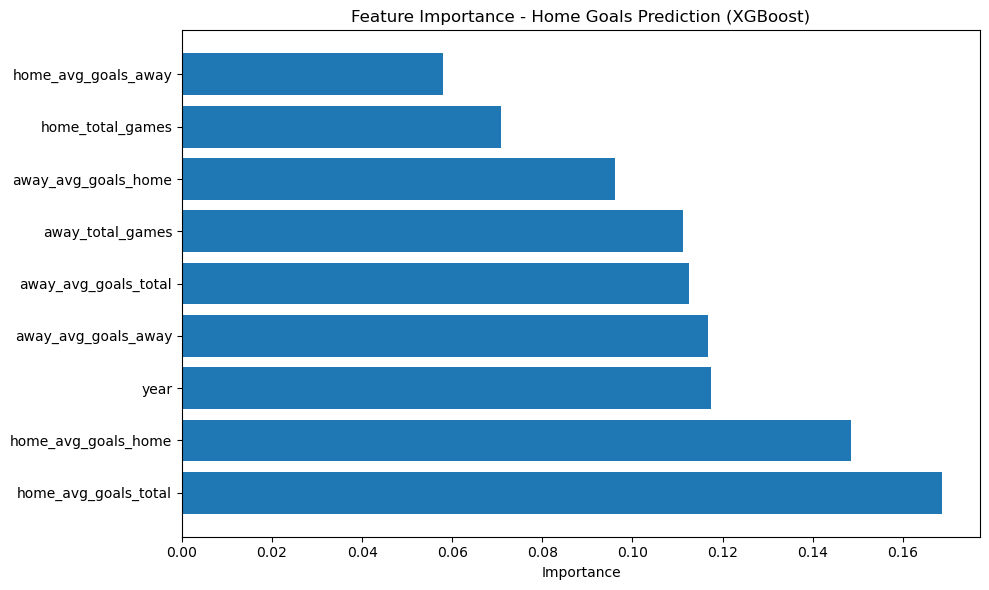

In [27]:
# Feature importance (for tree-based models)
print("🔍 FEATURE IMPORTANCE (XGBoost - Home Goals)\n")

xgb_model = models_home['XGBoost']['model']
feature_importance = xgb_model.feature_importances_

# Create dataframe for visualization
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Home Goals Prediction (XGBoost)')
plt.tight_layout()
plt.show()

### Step 10: Next Steps

Your models are now trained! Here are ways to improve:

1. **Add ELO Ratings** - Incorporate FIFA/ELO rankings
2. **Recent Form** - Calculate last 5 matches average
3. **Home Advantage** - Add binary home/away multiplier  
4. **Ensemble Voting** - Average predictions from all 4 models
5. **Hyperparameter Tuning** - Use GridSearchCV for optimal params
6. **Cross Validation** - Validate on multiple splits